# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [16]:
import numpy as np
np.set_printoptions(precision=2)

In [17]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define A L-Maze Grid World 

In [18]:
from gym_classics.envs.abstract.gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|          |
|        G |
|          |
| XXXXXX   |
|      X   |
|      X   |
|      X   |
|   S  X   |
|      X   |
|          |
"""

    def __init__(self):
        super().__init__(self.layout, n_actions = 4)
        
    def _next_state(self, state, action):
        next_state = self._move(state, action)
        if self._is_blocked(next_state):
            next_state = state
        return self._clamp(next_state), 1.0

    def _reward(self, state, action, next_state):      
        return {list(self._goals)[0]: +1.0}.get(next_state, 0.0)

    def _done(self, state, action, next_state):
        return next_state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment LMaze-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [19]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

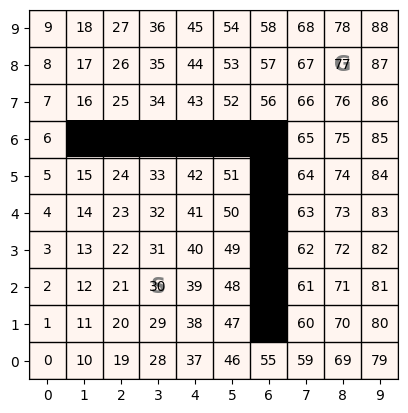

In [20]:
env.image()

In [21]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=1000)

[(30, 0, 0.0, 31),
 (31, 3, 0.0, 22),
 (22, 2, 0.0, 21),
 (21, 0, 0.0, 22),
 (22, 1, 0.0, 31),
 (31, 1, 0.0, 40),
 (40, 2, 0.0, 39),
 (39, 3, 0.0, 30),
 (30, 1, 0.0, 39),
 (39, 0, 0.0, 40),
 (40, 3, 0.0, 31),
 (31, 1, 0.0, 40),
 (40, 0, 0.0, 41),
 (41, 0, 0.0, 42),
 (42, 0, 0.0, 42),
 (42, 1, 0.0, 51),
 (51, 2, 0.0, 50),
 (50, 1, 0.0, 50),
 (50, 1, 0.0, 50),
 (50, 1, 0.0, 50),
 (50, 0, 0.0, 51),
 (51, 3, 0.0, 42),
 (42, 2, 0.0, 41),
 (41, 1, 0.0, 50),
 (50, 1, 0.0, 50),
 (50, 2, 0.0, 49),
 (49, 2, 0.0, 48),
 (48, 2, 0.0, 47),
 (47, 3, 0.0, 38),
 (38, 3, 0.0, 29),
 (29, 1, 0.0, 38),
 (38, 3, 0.0, 29),
 (29, 3, 0.0, 20),
 (20, 2, 0.0, 19),
 (19, 3, 0.0, 10),
 (10, 1, 0.0, 19),
 (19, 1, 0.0, 28),
 (28, 2, 0.0, 28),
 (28, 3, 0.0, 19),
 (19, 0, 0.0, 20),
 (20, 3, 0.0, 11),
 (11, 2, 0.0, 10),
 (10, 3, 0.0, 0),
 (0, 0, 0.0, 1),
 (1, 3, 0.0, 1),
 (1, 0, 0.0, 2),
 (2, 0, 0.0, 3),
 (3, 0, 0.0, 4),
 (4, 0, 0.0, 5),
 (5, 0, 0.0, 6),
 (6, 0, 0.0, 7),
 (7, 1, 0.0, 16),
 (16, 0, 0.0, 17),
 (17, 2, 0.

## Define Linear State Features

In [22]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa, state_features  

In [23]:
# overwrite state_features for the semi-gradient Sarsa implementation in gym_classics
def state_features(s):
    coord = env.decode(s)
    return np.concatenate([np.array([1]), np.array(coord)])

gym_classics.algorithms.linear_approximation.state_features = state_features

In [24]:
from gym_classics.algorithms.linear_approximation import q_hat
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    
    return Q, V, pol

Learn weights. This is a difficult problem so I use a high epsilon to increase exploration.

In [ ]:
w = semi_gradient_Sarsa(env, n=1000, epsilon=0.5, alpha=0.001, gamma=1, max_episode_length=1000, verbose=False)
Q, V, pol = plot_w(w)

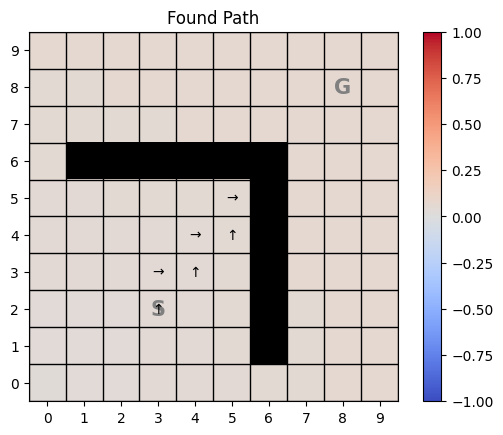

In [ ]:
path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))

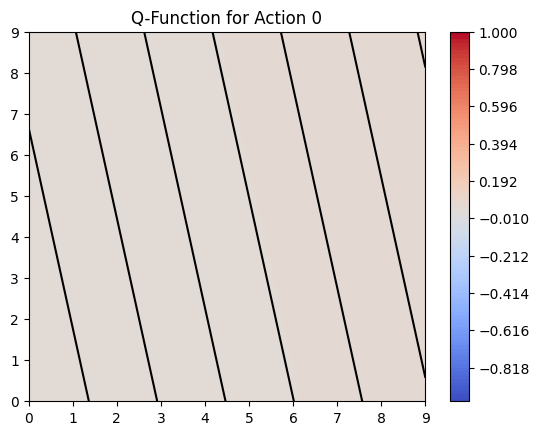

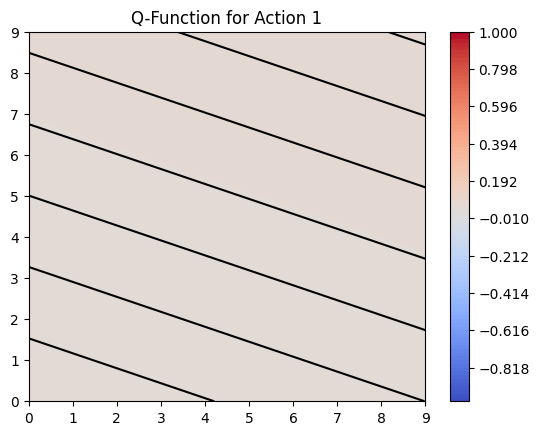

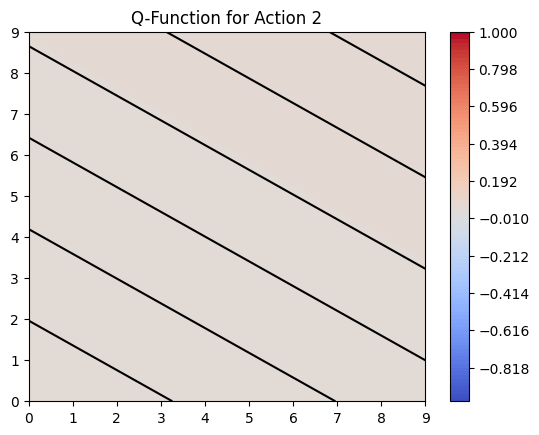

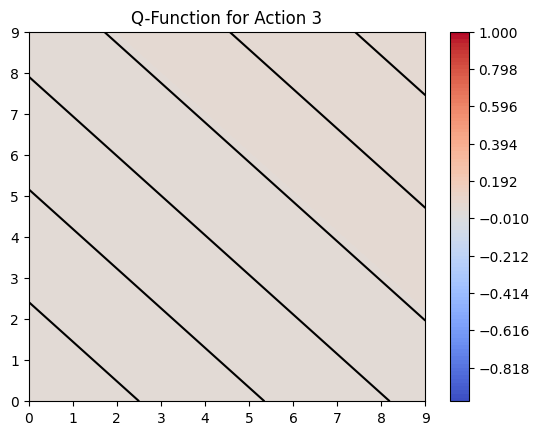

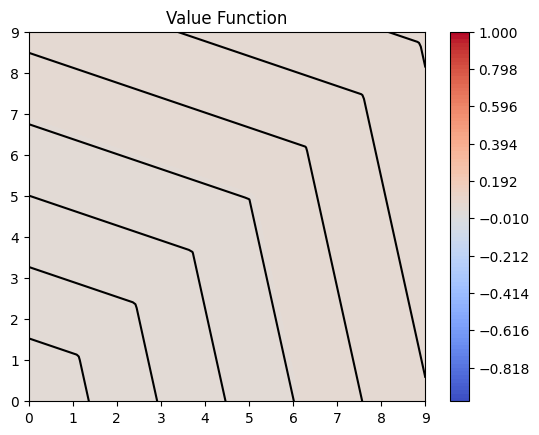

In [ ]:
from matplotlib import pyplot as plt

dim = (9,9)

def active_weights(a):
    return [0] + list(range(a*2+1, a*2+2+1))

def q_hat(s, a, w): 
    # mask predictions for going outside the grid
    state = env.decode(s)
    next_state = env._next_state(state, a)[0]
    if next_state == state:
        return -100
    
    return np.dot(w[active_weights(a)], state_features(s))

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])


x = np.linspace(0, dim[0], 100)
y = np.linspace(0, dim[1], 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.decode_action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


It is very unlikely that linear approximation works well for this problem! The agent will get stuck! We need to represent the states differently.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)